In [1]:
import json
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
dataset_dir = f'{parent_dir}/dataset'

with open(f'{dataset_dir}/mb_artists.json') as f:
    artists = json.load(f)
    
with open(f'{dataset_dir}/artists.json') as f:
    artists_og = json.load(f)

In [2]:
from integration import compute_match_scores

for (artist_og, artist_retrieved) in zip(artists_og, artists):
    compute_match_scores(artist_og, artist_retrieved)

In [3]:
scores_artists = []

for artist in artists:
    scores_artists.append(max([
        track_retrieved['matching-score']
        for track_retrieved in artist['artist-list']
    ]))

In [4]:
# top 5 lowest matching scores
sorted(scores_artists)[:10]

[0.4795137921181918,
 0.49463458307919494,
 0.5375962435422161,
 0.5801950863543067,
 0.6696128631297753,
 0.692638670019826,
 0.7101797993286063,
 0.752203400199369,
 0.8155749939822514,
 0.8654237002950796]

In [5]:
len(scores_artists), len(artists)

(104, 104)

In [6]:
for low_score in sorted(scores_artists)[:10]:
    idx = scores_artists.index(low_score)
    best_artist = max(
        artists[idx]['artist-list'],
        key=lambda t: t['matching-score']
    )
    print(f"{artists_og[idx]['name']}: {best_artist['name']}, {best_artist['matching-score']}")

miss simpatia: Name, 0.4795137921181918
joey funboy: Name, 0.49463458307919494
eva rea: Name, 0.5375962435422161
beba: Marina Barone, 0.5801950863543067
hindaco: Name, 0.6696128631297753
mike24: Name, 0.692638670019826
guè pequeno: Guè, 0.7101797993286063
alfa: Alpha DJ, 0.752203400199369
anna pepe: ANNA, 0.8155749939822514
rosa chemical: Rosa Chemical, 0.8654237002950796


In [7]:
for low_score in sorted(scores_artists)[:6]:
    idx = scores_artists.index(low_score)
    best_artist = max(
        artists[idx]['artist-list'],
        key=lambda t: t['matching-score']
    )
    print(f"{artists_og[idx]['name']}, {best_artist}")

miss simpatia, {'id': 'a61fcba5-f0a8-4c81-a188-d70acedfd8c5', 'type': 'Person', 'ext:score': '96', 'name': 'Name', 'sort-name': 'Name', 'gender': 'female', 'disambiguation': 'Clara Moroni, Eurobeat', 'life-span': {'ended': 'false'}, 'matching-score': 0.4795137921181918}
joey funboy, {'id': 'a61fcba5-f0a8-4c81-a188-d70acedfd8c5', 'type': 'Person', 'ext:score': '96', 'name': 'Name', 'sort-name': 'Name', 'gender': 'female', 'disambiguation': 'Clara Moroni, Eurobeat', 'life-span': {'ended': 'false'}, 'matching-score': 0.49463458307919494}
eva rea, {'id': 'a61fcba5-f0a8-4c81-a188-d70acedfd8c5', 'type': 'Person', 'ext:score': '96', 'name': 'Name', 'sort-name': 'Name', 'gender': 'female', 'disambiguation': 'Clara Moroni, Eurobeat', 'life-span': {'ended': 'false'}, 'matching-score': 0.5375962435422161}
beba, {'id': '0aa1fe1e-5e38-46e2-bb67-091507387e4c', 'type': 'Person', 'ext:score': '100', 'name': 'Marina Barone', 'sort-name': 'Barone, Marina', 'gender': 'female', 'country': 'IT', 'area': {'

In [8]:
artists[0].keys()

dict_keys(['artist-list', 'artist-count', 'id_author'])

In [35]:
artists_og[0].keys()

dict_keys(['id_author', 'name', 'gender', 'birth_date', 'birth_place', 'nationality', 'description', 'active_start', 'active_end', 'province', 'region', 'country', 'latitude', 'longitude'])

In [36]:
artists[0]['artist-list'][0].keys()

dict_keys(['id', 'type', 'ext:score', 'name', 'sort-name', 'country', 'area', 'begin-area', 'isni-list', 'life-span', 'alias-list', 'tag-list', 'matching-score'])

In [43]:
artists_og[1]

{'id_author': 'ART53496045',
 'name': 'achille lauro',
 'gender': 'M',
 'birth_date': '1990-07-11',
 'birth_place': 'Verona',
 'nationality': 'Italia',
 'description': 'cantautore e rapper italiano (1990-)',
 'active_start': '2012-01-01',
 'active_end': None,
 'province': 'Verona',
 'region': 'Veneto',
 'country': 'Italia',
 'latitude': 45.4424977,
 'longitude': 10.9857377}

In [42]:
artists[1]['artist-list'][0]

{'id': '790875e6-bf01-4a83-b81d-97d93588ccc7',
 'type': 'Person',
 'ext:score': '100',
 'name': 'Achille Lauro',
 'sort-name': 'Lauro, Achille',
 'gender': 'male',
 'country': 'IT',
 'area': {'id': 'c6500277-9a3d-349b-bf30-41afdbf42add',
  'type': 'Country',
  'name': 'Italy',
  'sort-name': 'Italy',
  'life-span': {'ended': 'false'}},
 'begin-area': {'id': 'e563fe8d-58bb-4f50-8393-2604ad4de5bf',
  'type': 'Municipality',
  'name': 'Verona',
  'sort-name': 'Verona',
  'life-span': {'ended': 'false'}},
 'disambiguation': 'Italian rapper Lauro De Marinis',
 'ipi-list': ['00737638900'],
 'isni-list': ['0000000466206546'],
 'life-span': {'begin': '1990-07-11', 'ended': 'false'},
 'alias-list': [{'locale': 'it_IT',
   'sort-name': 'Marinis, De, Lauro',
   'type': 'Legal name',
   'alias': 'Lauro De Marinis'}],
 'tag-list': [{'count': '1', 'name': '2010s'},
  {'count': '1', 'name': '2020s'},
  {'count': '1', 'name': 'pop rap'},
  {'count': '1', 'name': 'italian'},
  {'count': '1', 'name': 't

In [10]:
artists[51]['artist-list'][0]['sort-name']

'Marsiglia, Johnny'

In [11]:
# Count artists with zero, one or more results
zero = []
one = []
more = []

for artist in artists:
    if artist['artist-count'] == 0:
        zero.append(artist)
    elif artist['artist-count'] == 1:
        one.append(artist)
    else:
        more.append(artist)

len(zero), len(one), len(more)

(0, 83, 21)

In [12]:
# open track dumps
with open(f'{dataset_dir}/mb_tracks_1.json') as f:
    tracks = json.load(f)
    
with open(f'{dataset_dir}/mb_tracks_2.json') as f:
    tracks.extend(json.load(f))
    
with open(f'{dataset_dir}/tracks.json') as f:
    tracks_og = json.load(f)

In [13]:
tracks_og[0]['title'], tracks[0]['recording-list'][0]['title']

('\u200bpolka 2 :-/', 'polka 2 :-/')

In [14]:
from integration import matching_score_track

matching_score_track(tracks_og[0], tracks[0]['recording-list'][0])

0.9922826305292196

In [15]:
from integration import compute_match_scores

for (track_og, track_retrieved) in zip(tracks_og, tracks):
    compute_match_scores(track_og, track_retrieved)

In [16]:
tracks[11000]['recording-list'][0]['matching-score']

0.8073170609291235

In [17]:
scores = []
best_tracks_retrieved = []

for tracks_retrieved in tracks:
    scores.append(max([
        track_retrieved['matching-score']
        for track_retrieved in tracks_retrieved['recording-list']
    ]))
    best_tracks_retrieved.append(max(
        track_retrieved['recording-list'],
        key=lambda t: t['matching-score']
    ))

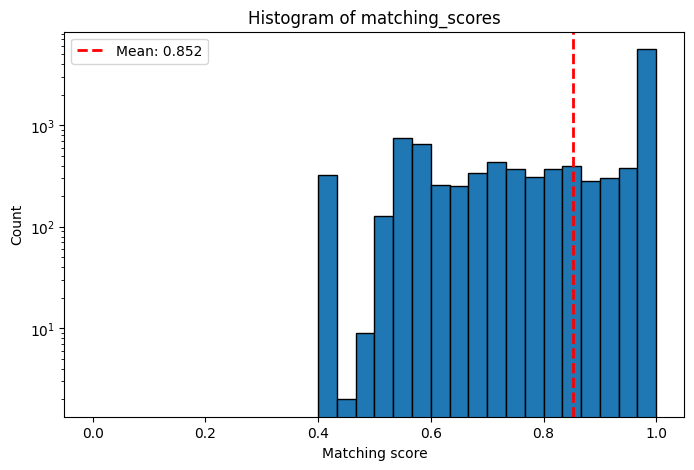

In [18]:
import matplotlib.pyplot as plt
from statistics import mean

plt.figure(figsize=(8,5))
m = mean(scores)
plt.hist(scores, bins=30, range=(0,1), edgecolor='black')
plt.xlabel('Matching score')
plt.ylabel('Count')
plt.title('Histogram of matching_scores')
plt.axvline(m, color='red', linestyle='--', linewidth=2, label=f"Mean: {m:.3f}")
plt.legend()
plt.yscale('log')
plt.show()

In [19]:
for low_score in sorted(scores)[:2500]:
    print(low_score)

0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416


In [20]:
tracks[0]['recording-list'][0].keys()

dict_keys(['id', 'ext:score', 'title', 'length', 'artist-credit', 'release-list', 'isrc-list', 'artist-credit-phrase', 'matching-score'])

In [21]:
matching_title_artists = []

for track_og, track_retrieved in zip(tracks_og, tracks):

    best_track = max(
        track_retrieved['recording-list'],
        key=lambda t: t['matching-score']
    )

    # normalize titles
    title_match = best_track['title'].lower() == track_og['title'].lower()

    # extract artist names correctly
    retrieved_artists = [
        credit['artist']['name'].lower()
        for credit in best_track['artist-credit']
        if isinstance(credit, dict) and 'artist' in credit and 'name' in credit['artist']
    ]

    og_artist = track_og['primary_artist'].lower()
    artist_match = og_artist in retrieved_artists

    if title_match and artist_match:
        matching_title_artists.append((best_track, track_og))


In [22]:
len(matching_title_artists)

6838

In [23]:
from statistics import mean

matching_scores_matches = []

for match in matching_title_artists:
    matching_scores_matches.append(match[0]['matching-score'])

mean(matching_scores_matches)

0.9653846355890838

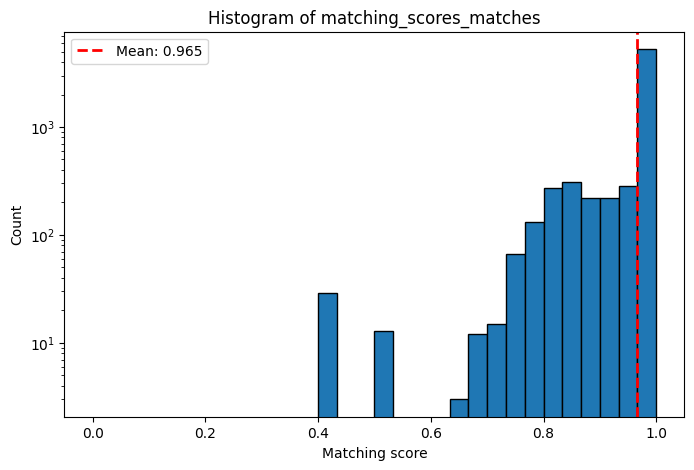

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
m = mean(matching_scores_matches)
plt.hist(matching_scores_matches, bins=30, range=(0,1), edgecolor='black')
plt.xlabel('Matching score')
plt.ylabel('Count')
plt.title('Histogram of matching_scores_matches')
plt.axvline(m, color='red', linestyle='--', linewidth=2, label=f"Mean: {m:.3f}")
plt.legend()
plt.yscale('log')
plt.show()

In [25]:
title_matching = []


for track_og, track_retrieved in zip(tracks_og, tracks):

    best_track = max(
        track_retrieved['recording-list'],
        key=lambda t: t['matching-score']
    )

    # normalize titles
    title_match = best_track['title'].lower() == track_og['title'].lower()

    # og_artist = track_og['primary_artist'].lower()
    # artist_match = og_artist in retrieved_artists

    if title_match:
        title_matching.append((best_track, track_og))

In [26]:
from statistics import mean

title_matching_scores = []

for title_match in title_matching:
    title_matching_scores.append(title_match[0]['matching-score'])

mean(title_matching_scores)

0.9362874578307696

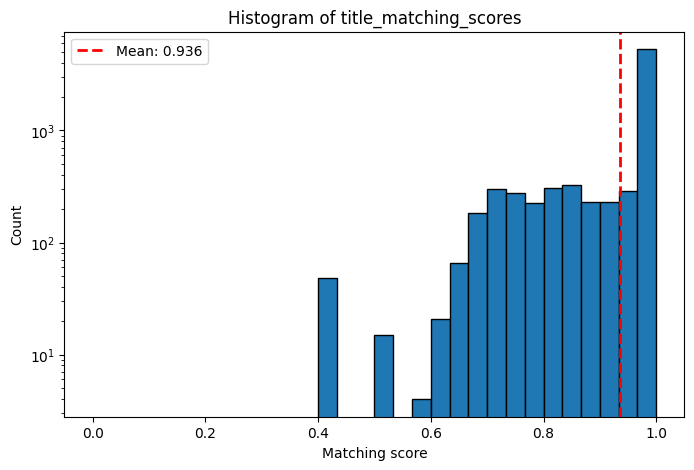

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
m = mean(title_matching_scores)
plt.hist(title_matching_scores, bins=30, range=(0,1), edgecolor='black')
plt.xlabel('Matching score')
plt.ylabel('Count')
plt.title('Histogram of title_matching_scores')
plt.axvline(m, color='red', linestyle='--', linewidth=2, label=f"Mean: {m:.3f}")
plt.legend()
plt.yscale('log')
plt.show()

In [28]:
not_matching = []


for track_og, track_retrieved in zip(tracks_og, tracks):

    best_track = max(
        track_retrieved['recording-list'],
        key=lambda t: t['matching-score']
    )

    # normalize titles
    title_match = best_track['title'].lower() == track_og['title'].lower()

    # extract artist names correctly
    retrieved_artists = [
        credit['artist']['name'].lower()
        for credit in best_track['artist-credit']
        if isinstance(credit, dict) and 'artist' in credit and 'name' in credit['artist']
    ]

    og_artist = track_og['primary_artist'].lower()
    artist_match = og_artist in retrieved_artists

    if not title_match and not artist_match:
        not_matching.append((best_track, track_og))

In [29]:
from statistics import mean

not_matching_scores = []

for not_match in not_matching:
    not_matching_scores.append(not_match[0]['matching-score'])

mean(not_matching_scores)

0.577327287301027

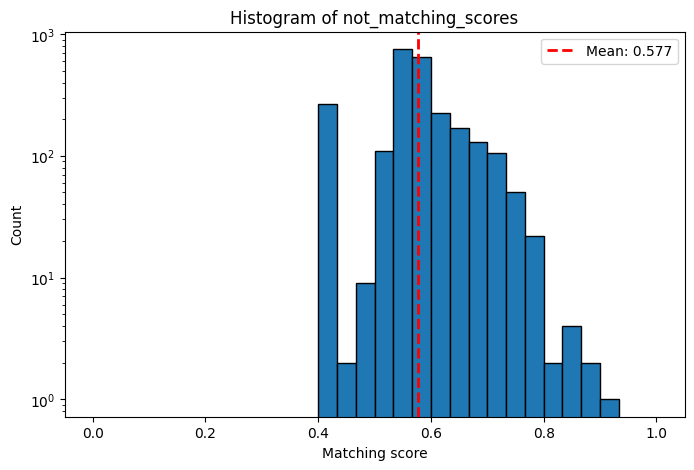

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
m = mean(not_matching_scores)
plt.hist(not_matching_scores, bins=30, range=(0,1), edgecolor='black')
plt.xlabel('Matching score')
plt.ylabel('Count')
plt.title('Histogram of not_matching_scores')
plt.axvline(m, color='red', linestyle='--', linewidth=2, label=f"Mean: {m:.3f}")
plt.legend()
plt.yscale('log')
plt.show()

In [31]:
# Count artists with zero, one or more results
zero = []
one = []
more = []

for track in tracks:
    if track['recording-count'] == 0:
        zero.append(track)
    elif track['recording-count'] == 1:
        one.append(track)
    else:
        more.append(track)

len(zero), len(one), len(more)

(0, 6594, 4572)

In [33]:
best_tracks_retrieved[0], tracks[0]

({'id': '3055e5cf-f891-43c1-a4ec-1d57b44c2b00',
  'ext:score': '100',
  'title': 'Sway',
  'length': '348800',
  'artist-credit': [{'name': 'Title',
    'artist': {'id': '3febfce2-4ecb-4aa1-b85f-77c06d03a722',
     'name': 'Title',
     'sort-name': 'Title'}}],
  'release-list': [{'id': '2f1dde73-ca7c-4444-bce7-c2fa99065ee0',
    'title': 'Moonfly',
    'status': 'Official',
    'release-group': {'id': '03488ec2-f2f2-3d31-91bc-32f0ce60b600',
     'title': 'Moonfly'},
    'medium-list': [{'position': '1',
      'format': 'CD',
      'track-list': [{'id': '0641b131-506c-3033-803e-95a46151be3f',
        'number': '10',
        'title': 'Sway',
        'length': '348800',
        'track_or_recording_length': '348800'}],
      'track-count': 11}],
    'medium-track-count': 11,
    'medium-count': 1}],
  'artist-credit-phrase': 'Title',
  'matching-score': 0.42264973081037416},
 {'recording-list': [{'id': '1ecea448-8ec9-4595-935f-ed3cebdc4a69',
    'ext:score': '100',
    'title': 'polka 2 :